## EDA - Telco Customer Churn Dataset

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

    Checking for null values

In [5]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

    Columns in dataset

In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

    Checking value counts

In [7]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [8]:
for col in df.columns:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts())
    print("\n")


--- Value Counts for CustomerID ---
CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


--- Value Counts for Count ---
Count
1    7043
Name: count, dtype: int64


--- Value Counts for Country ---
Country
United States    7043
Name: count, dtype: int64


--- Value Counts for State ---
State
California    7043
Name: count, dtype: int64


--- Value Counts for City ---
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Milford             4
Calpine             4
Standish            4
Tulelake            4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64


--- Value Counts for Zip Code ---
Zip Code
90003    5
90005    5
90006    5
90010    5
90015    5
        ..
96121    4
96124    4
96128    4
96134    4
96146    4
Na

    Dropping noise from data

In [10]:
df = df.drop(columns=['CustomerID', 'Count', 'Country', 'State', 'Churn Label', 'Churn Score', 'CLTV', 'City', 'Zip Code', 
    'Lat Long', 'Latitude', 'Longitude',])

In [12]:
df.shape

(7043, 21)

In [11]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Churn Reason'],
      dtype='str')

In [13]:
print(df[['Monthly Charges', 'Total Charges']].dtypes)

Monthly Charges    float64
Total Charges       object
dtype: object


In [14]:
# Changing some empty string to null and then 0
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

df['Total Charges'] = df['Total Charges'].fillna(0)

    Distribution of Monthly Charges by Churn Status

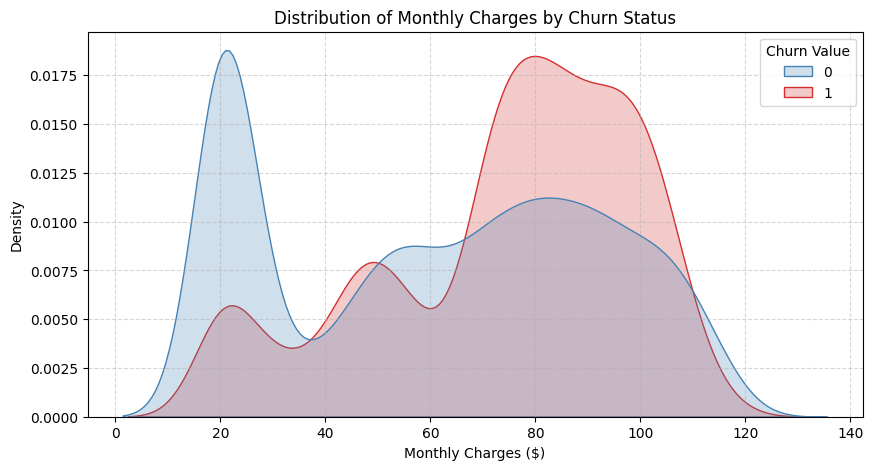

In [17]:
plt.figure(figsize=(10, 5))
# Density plot comparing Monthly Charges for staying vs leaving customers
sns.kdeplot(data=df, x="Monthly Charges", hue="Churn Value", fill=True, common_norm=False, palette=["#4682B4", "#D32F2F"])
plt.title("Distribution of Monthly Charges by Churn Status")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Density")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- This graph shows that high charges can be a reason for churn compared to low charges (not entirely true).

    Churn Counts Across Contract Types

In [19]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

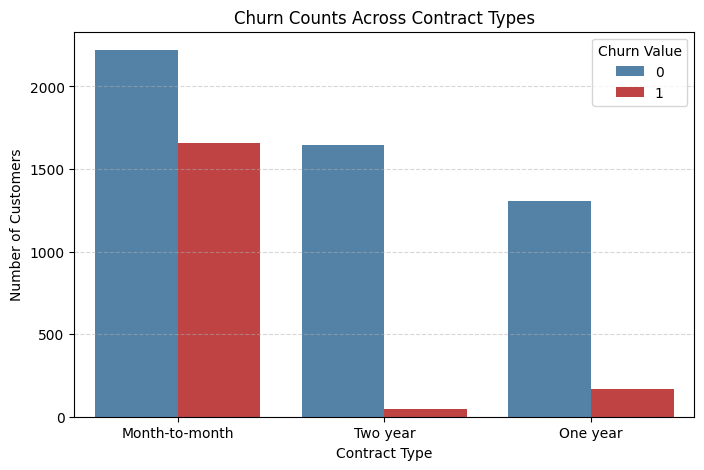

In [18]:
plt.figure(figsize=(8, 5))
# Countplot to check Churn across different contract lengths
sns.countplot(data=df, x="Contract", hue="Churn Value", palette=["#4682B4", "#D32F2F"])
plt.title("Churn Counts Across Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- Long term contract makes higher chances of customer to stay

    Impact of Tech Support on Customer Churn

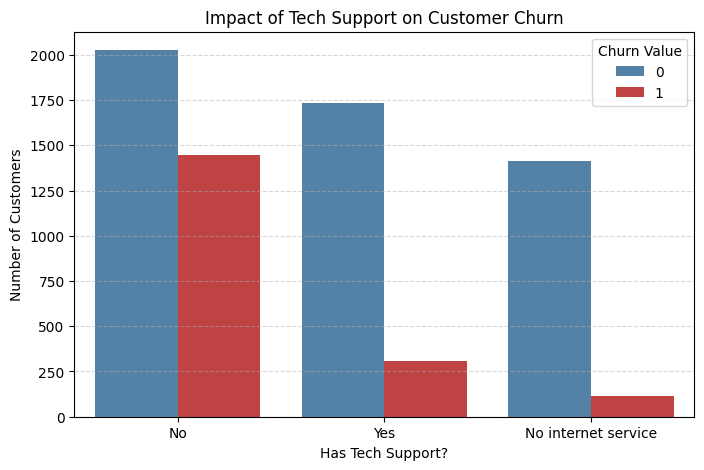

In [20]:
plt.figure(figsize=(8, 5))
# Checking if Tech Support availability changes churn behavior
sns.countplot(data=df, x="Tech Support", hue="Churn Value", palette=["#4682B4", "#D32F2F"])
plt.title("Impact of Tech Support on Customer Churn")
plt.xlabel("Has Tech Support?")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- No customer support leads to high chance of churn

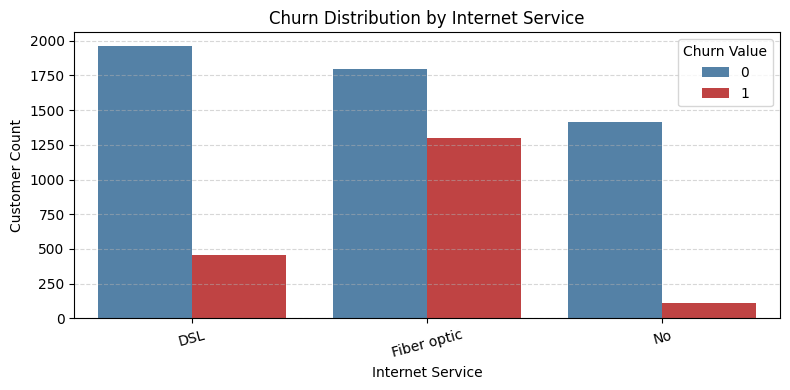

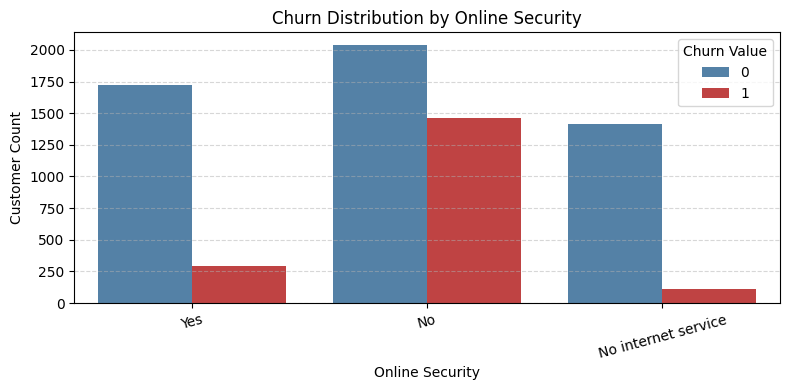

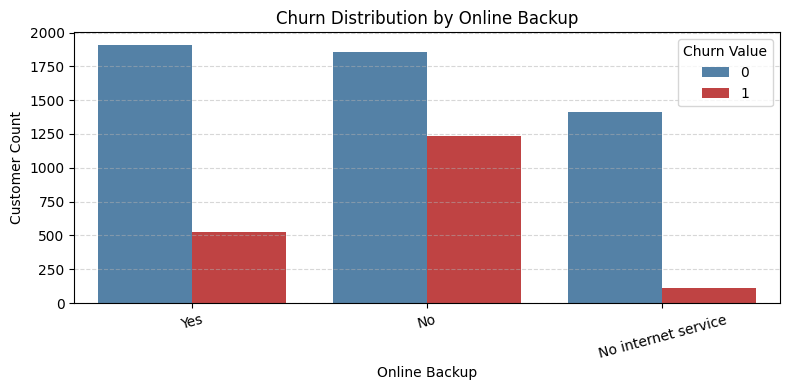

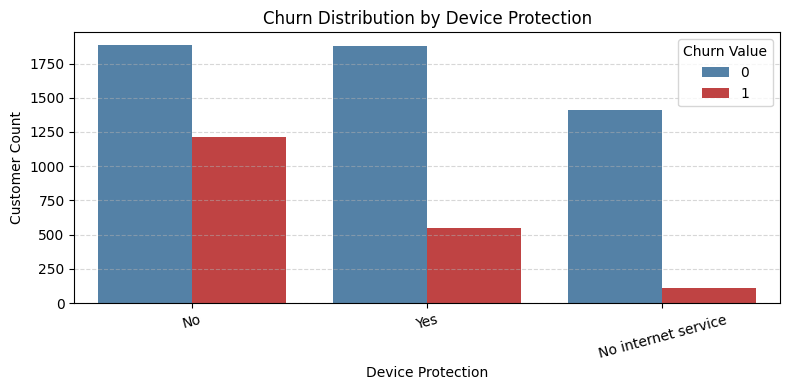

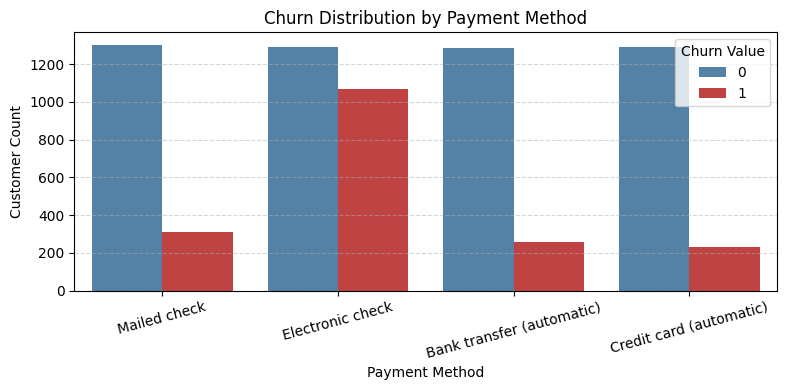

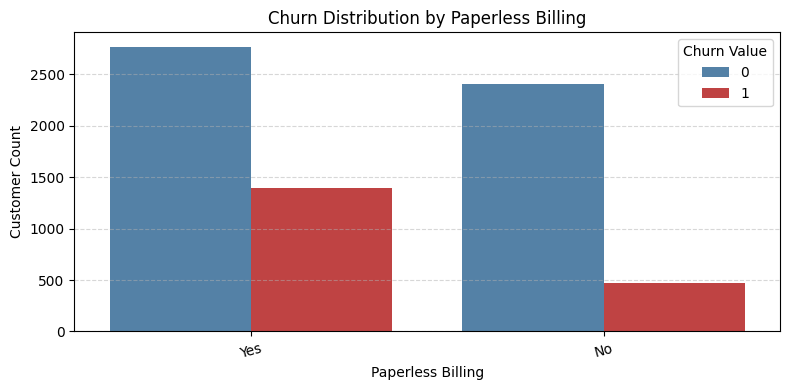

In [21]:
# Select the remaining categorical columns you want to inspect
target_columns = [
    'Internet Service', 'Online Security', 'Online Backup', 
    'Device Protection', 'Payment Method', 'Paperless Billing'
]

# Loop through and plot them dynamically
for col in target_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="Churn Value", palette=["#4682B4", "#D32F2F"])
    plt.title(f"Churn Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Customer Count")
    plt.xticks(rotation=15) # Rotates labels slightly so they don't overlap
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

1. Strange is that customers are more prone to churn having fiber optic better technology, reason can be high cost.
2. Customers with online security, online backup, and device protection along with internet service has more chance of staying (More products with internet more customer will stay).
3. Customers with automatic payment has more retention. Manual monthly payments create regular price friction; automated billing removes thought.
4. Paperless billing - digital native users exhibit less brand loyalty and switch providers easily.

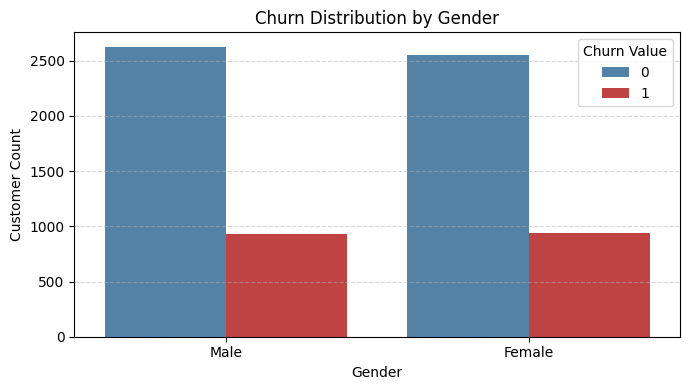

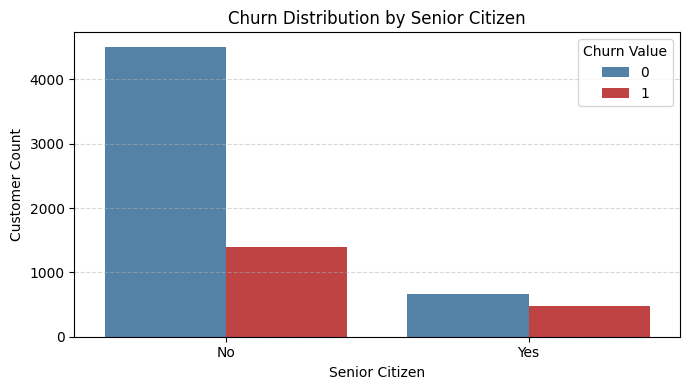

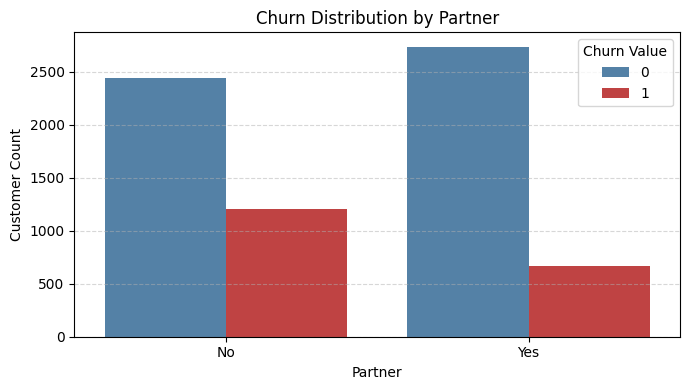

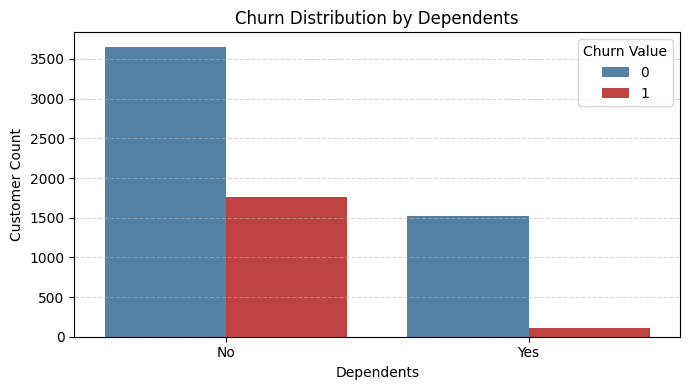

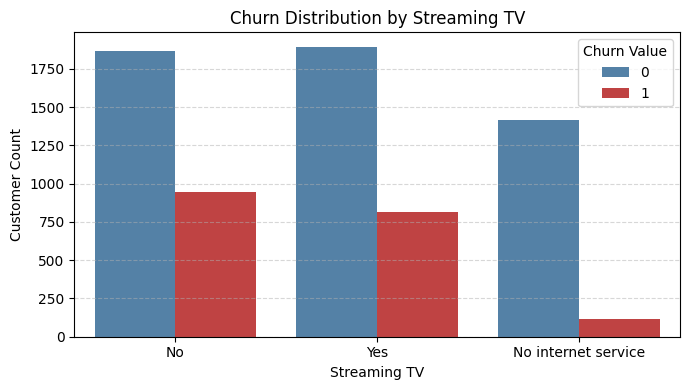

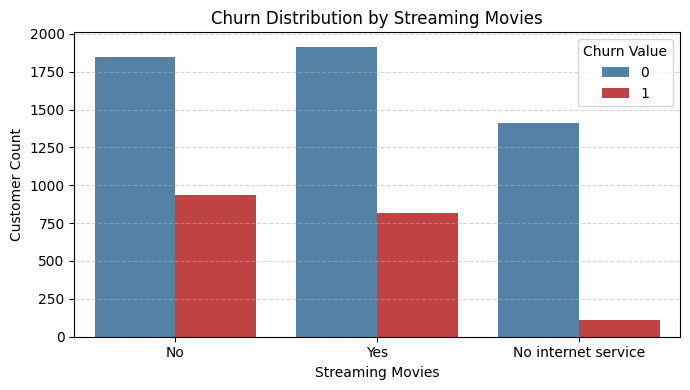

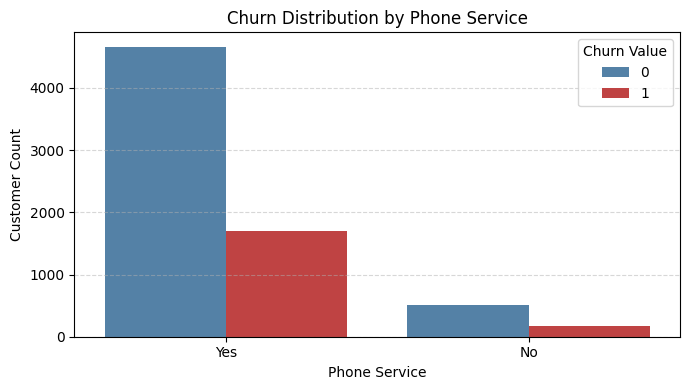

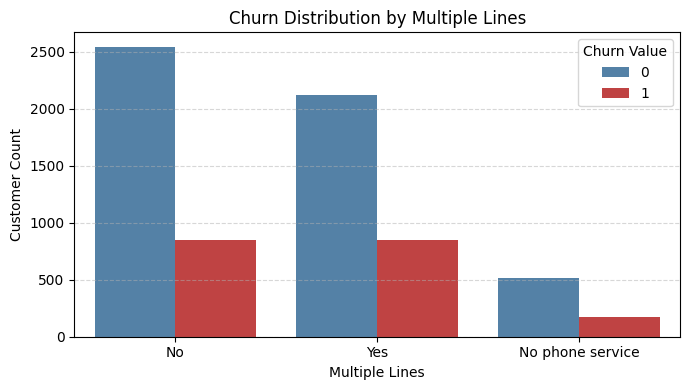

In [22]:
final_columns = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 
    'Streaming TV', 'Streaming Movies', 'Phone Service', 'Multiple Lines'
]

for col in final_columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="Churn Value", palette=["#4682B4", "#D32F2F"])
    plt.title(f"Churn Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Customer Count")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

1. Gender similar, almost negligible difference in churn.
2. Senior citizen has different arch in percentage they churn high but in total number is low.
3. No partner more chance of churn it is clear independent customers are more likely to churn, families are less likely to churn.
4. Streaming tv and movies has almost negligible difference in chunking.
5. Most of the customers have phone service, the data is imbalance and can't determine a direct relation with chunking.
6. Having single or multiple lines also don't determine a relation with chunking.

C:\Users\aksha\AppData\Local\Temp\ipykernel_15308\2576324730.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x="Churn Value", y="Tenure Months", palette=["#4682B4", "#D32F2F"])
C:\Users\aksha\AppData\Local\Temp\ipykernel_15308\2576324730.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x="Churn Value", y="Total Charges", palette=["#4682B4", "#D32F2F"])


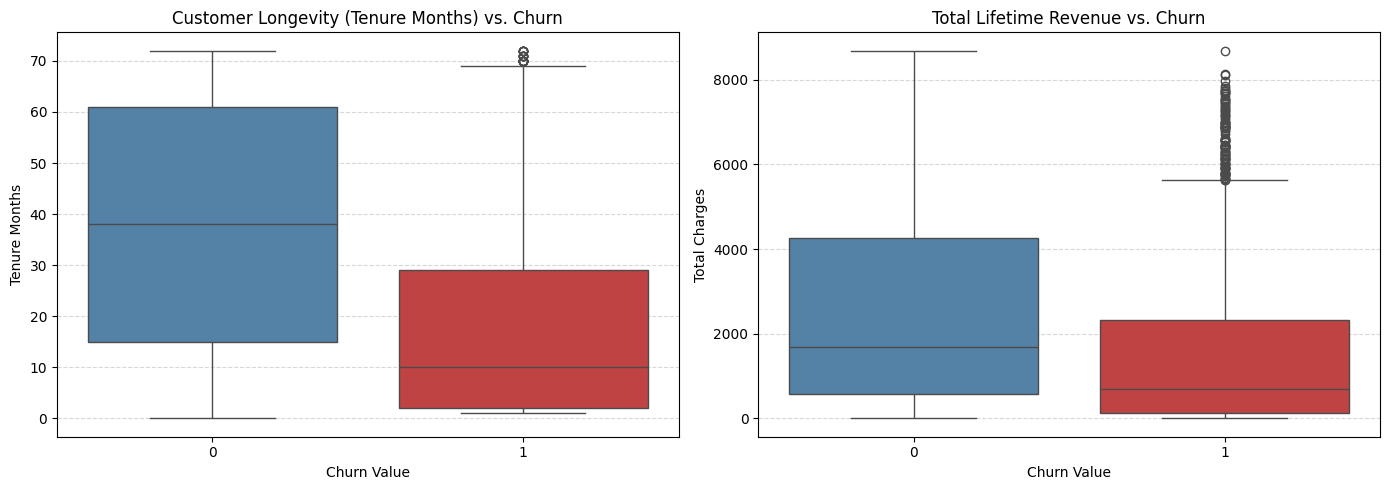

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure Months Analysis
sns.boxplot(ax=axes[0], data=df, x="Churn Value", y="Tenure Months", palette=["#4682B4", "#D32F2F"])
axes[0].set_title("Customer Longevity (Tenure Months) vs. Churn")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Total Charges Analysis
sns.boxplot(ax=axes[1], data=df, x="Churn Value", y="Total Charges", palette=["#4682B4", "#D32F2F"])
axes[1].set_title("Total Lifetime Revenue vs. Churn")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Customer Longevity (Tenure Months) Analysis
The longevity distribution reveals a critical early-stage retention crisis for the company, with the median tenure for churned customers sitting sharply at just 10 months. The heavy compression of the churned footprint between 1 and 12 months proves that the vast majority of customer loss happens within the first year of onboarding. Conversely, retained customers exhibit a high median stability of roughly 38 months, indicating that once a user survives the initial 18-month high-risk window, they successfully integrate into the ecosystem and become highly stable, long-term subscribers.

2. Total Lifetime Revenue (Total Charges) Analysis
The lifetime revenue distribution directly mirrors the tenure crisis, showing that the median spend for churned users sits heavily squashed below the $1,000 threshold. Because these customers exit the lifecycle so early, they leave before generating meaningful lifetime value, likely causing the company to lose money on its initial customer acquisition costs. However, the long tail of outlier dots stretching up to $8,000 highlights a small but highly damaging segment of elite, high-value accounts who stayed with the company for years before suddenly churning, representing the most expensive revenue losses for the business.

    Reasons for Customer Churn

C:\Users\aksha\AppData\Local\Temp\ipykernel_15308\4180197213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reasons.values, y=top_reasons.index, palette="mako")


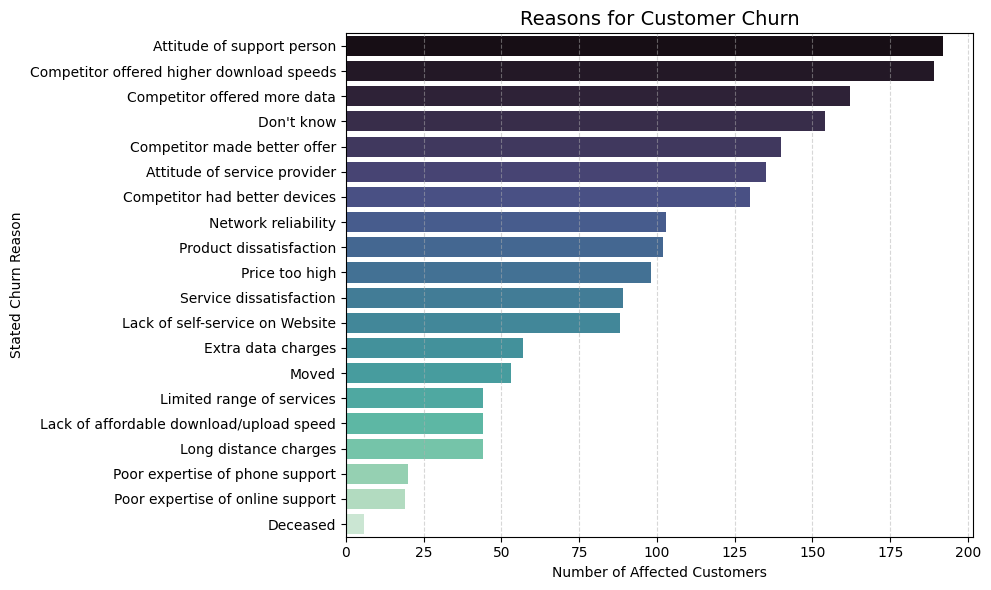

In [26]:
plt.figure(figsize=(10, 6))

# Isolate churned customers and grab the top 10 most common complaints
top_reasons = df[df['Churn Value'] == 1]['Churn Reason'].value_counts()

sns.barplot(x=top_reasons.values, y=top_reasons.index, palette="mako")
plt.title("Reasons for Customer Churn", fontsize=14)
plt.xlabel("Number of Affected Customers")
plt.ylabel("Stated Churn Reason")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Stated Churn Reason Complete Qualitative Analysis

The full categorical breakdown reveals that customer attrition is a complex mix of poor human touchpoints, aggressive market competition, and completely unpredictable real-world events. While internal service friction ("Attitude of support person") and external competitive pressure ("higher download speeds", "more data") dominate the highest tiers of customer loss, the bottom of the chart introduces crucial qualitative context like "Moved" and "Deceased". These lower-tier categories highlight the exact analytical boundary of the dataset: they represent unpreventable, involuntary churn events that leave no predictive trace in historical transactional data. By plotting the full spectrum of reasons, it becomes evident that while a machine learning model can accurately flag high-paying, month-to-month users vulnerable to competitive poaching, a portion of the target variable remains fundamentally unpredicatable due to these organic life events.

In [29]:
df.describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370
std,24.559481,30.090047,2266.794470,0.441561
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000
max,72.000000,118.750000,8684.800000,1.000000


--- Pandas Correlation Matrix ---
                 Tenure Months  Monthly Charges  Total Charges  Churn Value
Tenure Months         1.000000         0.247900       0.826178    -0.352229
Monthly Charges       0.247900         1.000000       0.651174     0.193356
Total Charges         0.826178         0.651174       1.000000    -0.198324
Churn Value          -0.352229         0.193356      -0.198324     1.000000




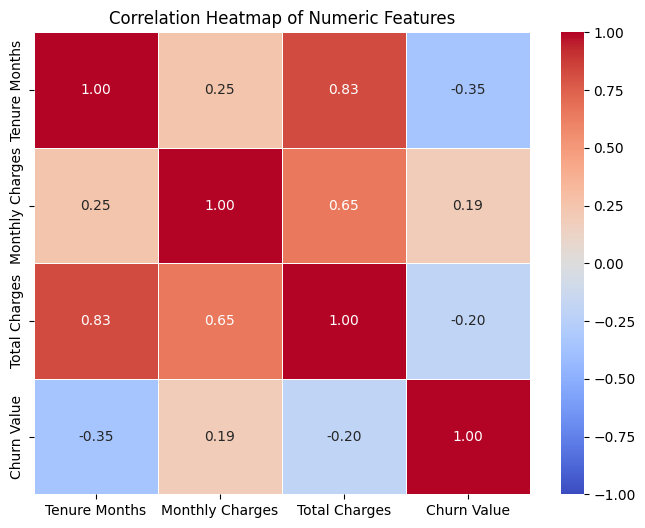

In [30]:

numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']

print("--- Pandas Correlation Matrix ---")
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)
print("\n")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the exact correlation numbers
    cmap='coolwarm',     # Red for positive correlation, Blue for negative
    fmt=".2f",           # Rounds to 2 decimal places
    linewidths=0.5,
    vmin=-1, vmax=1      # Locks the color scale from -1 to 1
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()